# 계절 확장 분석 (Seasonal Expansion Analysis)

```text
 Seasonal Expansion Analysis
   ├── Summer transition months (May–September)
   ├── Winter transition months (November–March)
   └── Heatmaps ⭐
```

Seasonal Expansion Analysis에서는 핵심적으로 다음 질문을 검증한다.

* 여름: 기존 6~8월 → 5월과 9월까지 여름다운 기온이 확대되고 있는가?
* 겨울: 기존 12~2월 → 11월과 3월까지 겨울다운 기온이 확대되고 있는가?

여기서는 앞에서 만든 `summer_like`와 `winter_like`를 사용한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df2 = pd.read_csv("../data/processed/dataset_processed.csv")
df2["date"] = pd.to_datetime(df2["date"])

## 1. Monthly summer/winter-like ratios

`summer_like`와 `winter_like`가 0/1이므로 `mean()`을 사용하면 해당 월에서 조건을 만족하는 날의 비율이 된다.

In [2]:
# 2026년 8월 뺀 데이터셋
monthly_ratio = pd.read_csv("../data/processed/monthly_ratio.csv")

monthly_ratio["summer_like_percent"] = (monthly_ratio["summer_like_ratio"] * 100)
monthly_ratio["winter_like_percent"] = (monthly_ratio["winter_like_ratio"] * 100)

print(monthly_ratio.head())
print(monthly_ratio.tail())

   year  month  summer_like_ratio  winter_like_ratio  summer_like_percent  \
0  1907     10                0.0           0.000000                  0.0   
1  1907     11                0.0           0.400000                  0.0   
2  1907     12                0.0           1.000000                  0.0   
3  1908      1                0.0           1.000000                  0.0   
4  1908      2                0.0           0.965517                  0.0   

   winter_like_percent  
0             0.000000  
1            40.000000  
2           100.000000  
3           100.000000  
4            96.551724  
      year  month  summer_like_ratio  winter_like_ratio  summer_like_percent  \
1382  2026      3           0.000000           0.225806             0.000000   
1383  2026      4           0.066667           0.000000             6.666667   
1384  2026      5           0.483871           0.000000            48.387097   
1385  2026      6           1.000000           0.000000           1

여름의 확장을 보기 위해 5~9월, 겨울의 확장을 보기 위해 11~3월을 본다:

In [3]:
summer_transition = monthly_ratio[monthly_ratio["month"].isin([5, 6, 7, 8, 9])].copy()
winter_transition = monthly_ratio[monthly_ratio["month"].isin([11, 12, 1, 2, 3])].copy()

## 2. Summer expansion

(1) 5월의 여름다운 날의 %이 최대 52%, 9월은 최대 97%임을 알 수 있다:

In [4]:
summer_edge_months = summer_transition[summer_transition["month"].isin([5, 9])]

summer_edge_summary = (
    summer_edge_months
    .groupby("month")["summer_like_percent"]
    .agg(["mean", "min", "max"])
)

print(summer_edge_summary)

            mean   min        max
month                            
5      17.547275   0.0  51.612903
9      62.982456  20.0  96.666667


(2) 5월과 9월 트렌드:

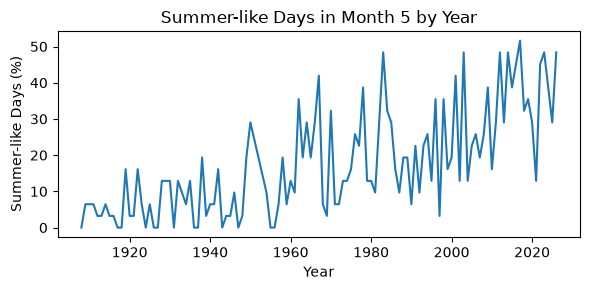

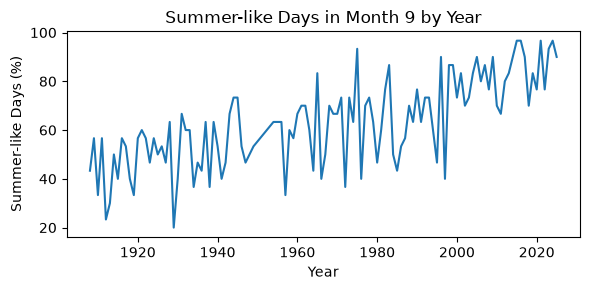

In [5]:
for month in [5, 9]:
    data = summer_transition[summer_transition["month"] == month]
    plt.figure(figsize=(6, 3))
    plt.plot(data["year"], data["summer_like_percent"])
    plt.xlabel("Year")
    plt.ylabel("Summer-like Days (%)")
    plt.title(f"Summer-like Days in Month {month} by Year")
    plt.tight_layout()
    plt.show()

* 그래프를 보면 5월과 9월에 여름다운 날의 비율이 증가하고 있음을 확인할 수 있다. 특히 9월은 80-100%로 여름다운 날(일평균기온 >= 20°C)의 비율이 증가하고 있다.

(3) Summer transition heatmap:

In [6]:
# 데이터를 heatmap 형태로 변환

summer_heatmap = (
    summer_transition
    .pivot(
        index="year",
        columns="month",
        values="summer_like_percent"
    )
)

print(summer_heatmap.head())
print(summer_heatmap.tail())

month         5          6           7           8          9
year                                                         
1908   0.000000  66.666667  100.000000   93.548387  43.333333
1909   6.451613  63.333333   96.774194  100.000000  56.666667
1910   6.451613  46.666667   93.548387  100.000000  33.333333
1911   6.451613  56.666667  100.000000  100.000000  56.666667
1912   3.225806  70.000000   96.774194   96.774194  23.333333
month          5           6      7           8          9
year                                                      
2022   45.161290   93.333333  100.0   96.774194  76.666667
2023   48.387097  100.000000  100.0  100.000000  93.333333
2024   38.709677  100.000000  100.0  100.000000  96.666667
2025   29.032258  100.000000  100.0  100.000000  90.000000
2026   48.387097  100.000000  100.0         NaN        NaN


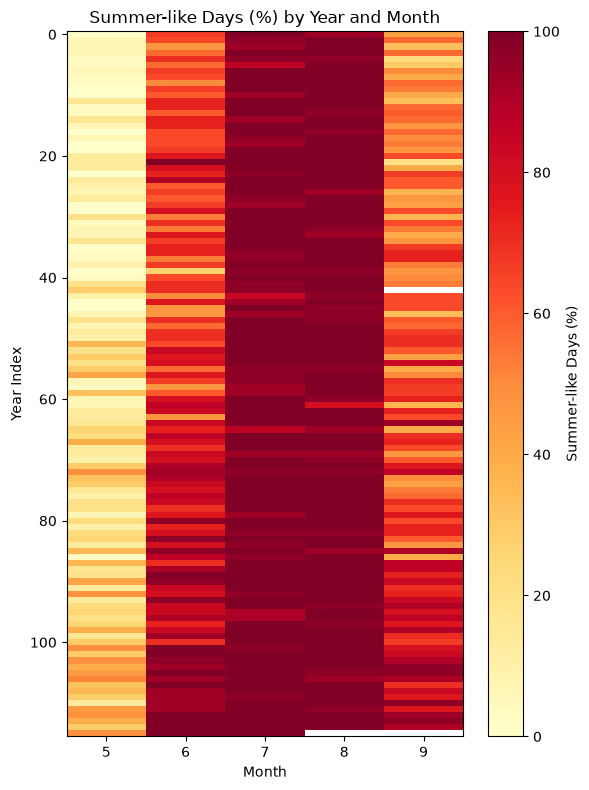

In [7]:
# heatmap

plt.figure(figsize=(6, 8))
plt.imshow(summer_heatmap, aspect="auto", interpolation="nearest", cmap="YlOrRd")
plt.colorbar(label="Summer-like Days (%)")
plt.xticks(range(len(summer_heatmap.columns)), summer_heatmap.columns)
plt.xlabel("Month")
plt.ylabel("Year Index")
plt.title("Summer-like Days (%) by Year and Month")
plt.tight_layout()
plt.show()

* Heatmap에서도 확인할 수 있듯이 7월과 8월은 본래 여름다운 날씨를 보인다. 한편 5,6,9월은 최근으로 갈수록(하단으로 갈수록) 색이 점점 짙어지는 경향을 보인다. 특히 9월이 높은 %으로 여름다운 날씨를 띄고 있는 것이 관찰된다.

## 3. Winter contraction

(1) 3월의 겨울다운 날의 %이 최대 100%, 11월은 최대 77%임을 알 수 있다:

In [10]:
winter_edge_months = winter_transition[winter_transition["month"].isin([11, 3])]

winter_edge_summary = (
    winter_edge_months
    .groupby("month")["winter_like_percent"]
    .agg(["mean", "min", "max"])
)

print(winter_edge_summary)

           mean       min         max
month                                
3      53.14238  9.677419  100.000000
11     36.57971  6.666667   76.666667


(2) 3월과 11월 트렌드:

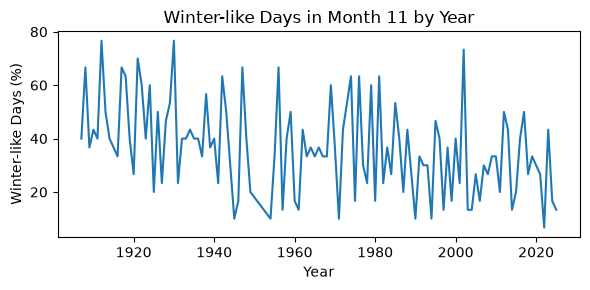

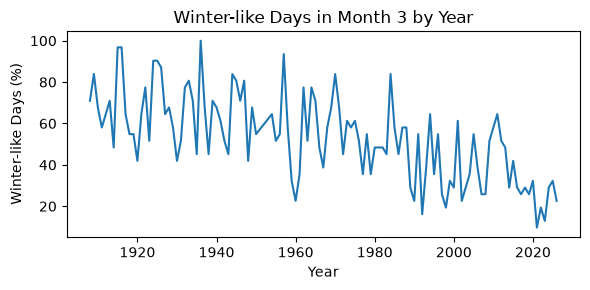

In [11]:
for month in [11, 3]:
    data = winter_transition[winter_transition["month"] == month]
    plt.figure(figsize=(6, 3))
    plt.plot(data["year"], data["winter_like_percent"])
    plt.xlabel("Year")
    plt.ylabel("Winter-like Days (%)")
    plt.title(f"Winter-like Days in Month {month} by Year")
    plt.tight_layout()
    plt.show()

* 그래프를 보면 3월과 11월에 겨울다운 날의 비율이 축소하고 있음을 확인할 수 있다. 특히 3월은 겨울다운 날(일평균온도 <= 5°C)이 ~20%로 축소하고 있다.

(3) Winter transition heatmap:

In [12]:
# 데이터를 heatmap 형태로 변환

winter_heatmap = (
    winter_transition
    .pivot(
        index="year",
        columns="month",
        values="winter_like_percent"
    )
)

print(winter_heatmap.head())
print(winter_heatmap.tail())

month          1           2          3          11          12
year                                                           
1907          NaN         NaN        NaN  40.000000  100.000000
1908   100.000000   96.551724  70.967742  66.666667  100.000000
1909   100.000000  100.000000  83.870968  36.666667   96.774194
1910   100.000000  100.000000  67.741935  43.333333  100.000000
1911    96.774194  100.000000  58.064516  40.000000   96.774194
month          1          2          3          11          12
year                                                          
2022   100.000000  92.857143  19.354839   6.666667  100.000000
2023    90.322581  92.857143  12.903226  43.333333   67.741935
2024    96.774194  75.862069  29.032258  16.666667   90.322581
2025    96.774194  92.857143  32.258065  13.333333   90.322581
2026   100.000000  64.285714  22.580645        NaN         NaN


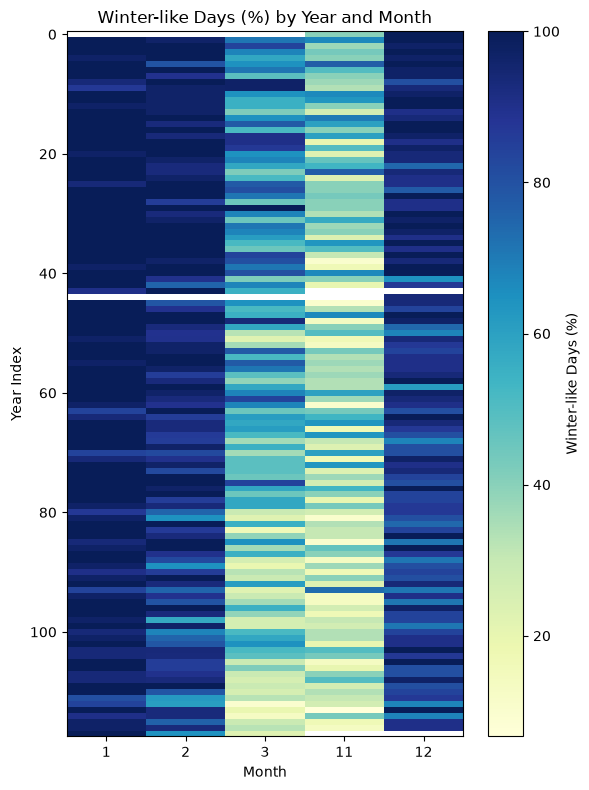

In [13]:
# heatmap

plt.figure(figsize=(6, 8))
plt.imshow(winter_heatmap, aspect="auto", interpolation="nearest", cmap="YlGnBu")
plt.colorbar(label="Winter-like Days (%)")
plt.xticks(range(len(winter_heatmap.columns)), winter_heatmap.columns)
plt.xlabel("Month")
plt.ylabel("Year Index")
plt.title("Winter-like Days (%) by Year and Month")
plt.tight_layout()
plt.show()

* Heatmap에서 확인할 수 있듯이 1월은 겨울철 기온 특성을 유지하고 있으나 2,3월 그리고 11,12월은 최근(하단)으로 갈수록 색이 연해지면서 겨울다운 날씨의 %가 감소하고 있다. 특히 3월의 겨울다운 날씨가 감소하고 있는 경향이 관찰된다.

* 여름과 겨울의 Heatmap에서 볼 수 있듯이 여름철 기온 특성을 가지는 달이 확장하고 있고 겨울철 기온 특성을 가지는 달이 축소하고 있는 것을 관찰할 수 있다.

## 4. Direct comparision: early vs. recent period 

In [14]:
# 전체 기간을 두 개의 기간으로 나눠 비교 (각 28년)
early_period = monthly_ratio[monthly_ratio["year"].between(1908, 1935)]     # 1907 제외
recent_period = monthly_ratio[monthly_ratio["year"].between(1998, 2025)]    # 2026 제외

# 여름
early_summer = early_period.groupby("month")["summer_like_percent"].mean()
recent_summer = recent_period.groupby("month")["summer_like_percent"].mean()

# 겨울
early_winter = early_period.groupby("month")["winter_like_percent"].mean()
recent_winter = recent_period.groupby("month")["winter_like_percent"].mean()

(1) Summer early vs. recent visualization:

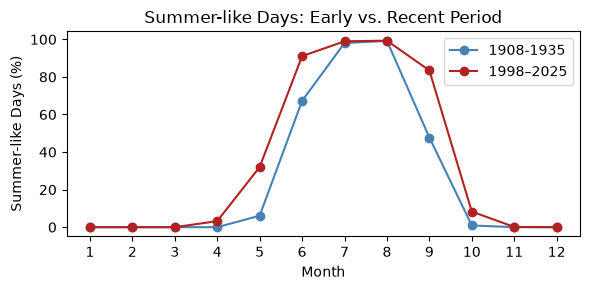

In [ ]:
months = list(range(1, 13))

plt.figure(figsize=(6, 3))
plt.plot(months, early_summer.loc[months], marker="o", label="1908-1935", color="steelblue")
plt.plot(months, recent_summer.loc[months], marker="o", label="1998-2025", color="firebrick")
plt.xlabel("Month")
plt.ylabel("Summer-like Days (%)")
plt.title("Summer-like Days: Early vs. Recent Period")
plt.xticks(months)
plt.legend()
plt.tight_layout()
plt.show()

* 5,6월 그리고 9월의 여름다운 날 %가 증가하므로 여름의 양쪽 경계가 확장되고 있을 가능성이 보인다.

(2) Winter early vs. recent visualization:

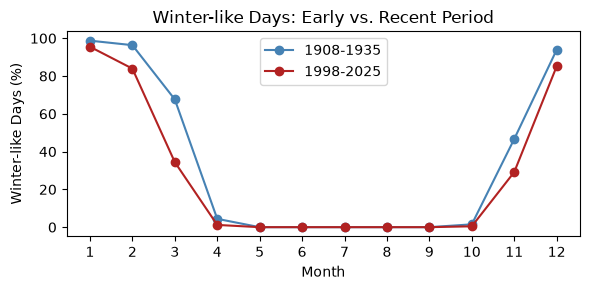

In [16]:
months = list(range(1, 13))

plt.figure(figsize=(6, 3))
plt.plot(months, early_winter.loc[months], marker="o", label="1908-1935", color="steelblue")
plt.plot(months, recent_winter.loc[months], marker="o", label="1998-2025", color="firebrick")
plt.xlabel("Month")
plt.ylabel("Winter-like Days (%)")
plt.title("Winter-like Days: Early vs. Recent Period")
plt.xticks(months)
plt.legend()
plt.tight_layout()
plt.show()

* 2, 3월 그리고 11월의 겨울다운 날 %가 감소하므로 겨울의 양쪽 경계가 축소되고 있을 가능성이 보인다.

## 5. Quantify the change in May/September/November/March

마지막으로 변화량을 계산한다.

In [17]:
transition_change = pd.DataFrame({
    "month": [5, 9, 11, 3],
    "early_percent": [
        early_summer.loc[5],
        early_summer.loc[9],
        early_winter.loc[11],
        early_winter.loc[3]
    ],
    "recent_percent": [
        recent_summer.loc[5],
        recent_summer.loc[9],
        recent_winter.loc[11],
        recent_winter.loc[3]
    ]
})

transition_change["change_percentage_points"] = (
    transition_change["recent_percent"]
    - transition_change["early_percent"]
)

print(transition_change)

   month  early_percent  recent_percent  change_percentage_points
0      5       6.105991       32.027650                 25.921659
1      9      47.738095       83.452381                 35.714286
2     11      46.666667       29.166667                -17.500000
3      3      67.626728       34.447005                -33.179724


* Recent vs. Early 대비 5,9월의 summer-like 비율 증가(+26pp, +36pp)와 11, 3월의 winter-like 감소(-18pp, -33pp)를 볼 수 있다.
    * 이는 5월과 9월의 여름 유사 기온 발생 비율이 확장되고 있음을 알려주는 증거이지만, 여름이 실제로 5~9월로 확장되었는지는 이후 통계적 추세 검정을 통해 확인하기로 한다.
    * 이는 11월과 3월의 겨울 유사 기온 발생 비율이 감소하고 있음을 알겨주는 증거이지만, 겨울이 실제로 축소되고 있는지는 이후 통계적 추세 검정을 통해 확인하기로 한다.

## 6. 통계적 검증 (Linear Regression & Mann-Kendall)

In [19]:
# 함수 생성

from scipy import stats
import pymannkendall as mk

def analyze_trend(data, month, variable, season_name):
    """
    Perform Linear Regression and Mann-Kendall
    trend analysis for a specific month.
    """

    monthly_data = data[data["month"] == month].dropna(subset=[variable]).sort_values("year").copy()

    x = monthly_data["year"]
    y = monthly_data[variable]

    # -----------------------------
    # Linear Regression
    # -----------------------------
    slope, intercept, r_value, p_value, std_err = (stats.linregress(x, y))

    r_squared = r_value ** 2

    # -----------------------------
    # Mann-Kendall Test
    # -----------------------------
    mk_result = mk.original_test(y)

    # -----------------------------
    # Print Results
    # -----------------------------
    print("=" * 60)
    print(f"{season_name} - Month {month}")
    print("=" * 60)

    print("\n[Linear Regression]")
    print(f"Slope: {slope:.6f} percentage points/year")
    print(f"Intercept: {intercept:.4f}")
    print(f"R²: {r_squared:.4f}")
    print(f"p-value: {p_value:.6g}")
    print(f"Change per 100 years: {slope * 100:.2f} percentage points")

    print("\n[Mann-Kendall Test]")
    print(f"Trend: {mk_result.trend}")
    print(f"p-value: {mk_result.p:.6g}")
    print(f"Sen's slope: {mk_result.slope:.6f}")

    # -----------------------------
    # Visualization
    # -----------------------------
    trend_line = intercept + slope * x

    plt.figure(figsize=(8, 4))
    plt.scatter(x, y, s=15, color="black", label="Observed")
    plt.plot(x, trend_line, color="blue", linewidth=2, label=f"Linear Trend (slope={slope:.3f})")
    plt.xlabel("Year")
    plt.ylabel(f"{season_name}-like Days (%)")
    plt.title(f"{season_name}-like Days in Month {month}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return {
        "season": season_name,
        "month": month,
        "slope": slope,
        "r_squared": r_squared,
        "linear_p_value": p_value,
        "change_per_100_years": slope * 100,
        "mk_trend": mk_result.trend,
        "mk_p_value": mk_result.p,
        "sen_slope": mk_result.slope
    }

Summer - Month 5

[Linear Regression]
Slope: 0.294130 percentage points/year
Intercept: -561.1205
R²: 0.5045
p-value: 4.31375e-19
Change per 100 years: 29.41 percentage points

[Mann-Kendall Test]
Trend: increasing
p-value: 2.22045e-16
Sen's slope: 0.286738


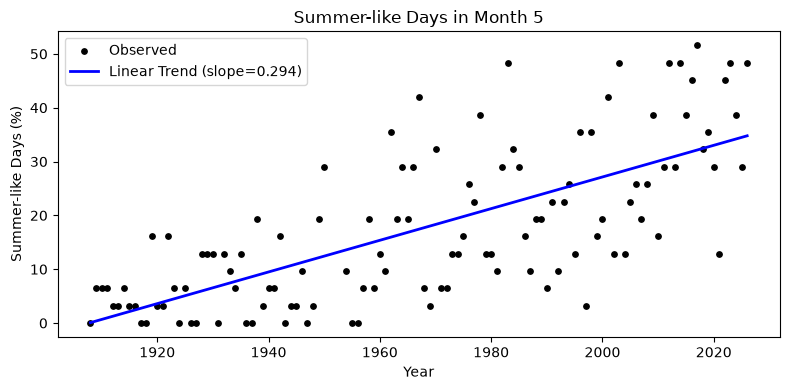

Summer - Month 9

[Linear Regression]
Slope: 0.365840 percentage points/year
Intercept: -656.6352
R²: 0.5035
p-value: 9.80509e-19
Change per 100 years: 36.58 percentage points

[Mann-Kendall Test]
Trend: increasing
p-value: 2.22045e-16
Sen's slope: 0.386473


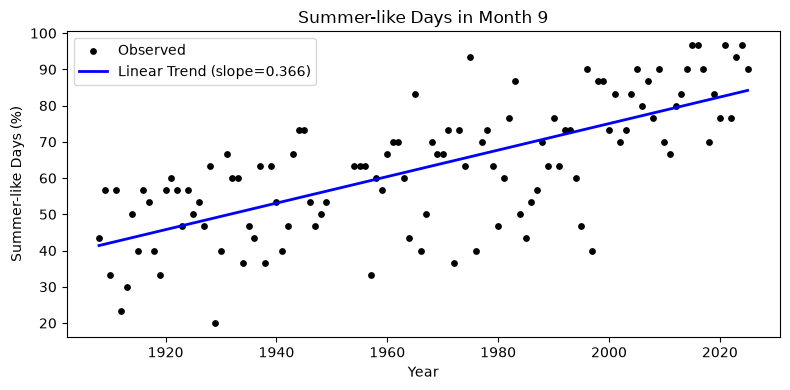

Winter - Month 11

[Linear Regression]
Slope: -0.182247 percentage points/year
Intercept: 394.9694
R²: 0.1422
p-value: 3.25944e-05
Change per 100 years: -18.22 percentage points

[Mann-Kendall Test]
Trend: decreasing
p-value: 4.6815e-05
Sen's slope: -0.181159


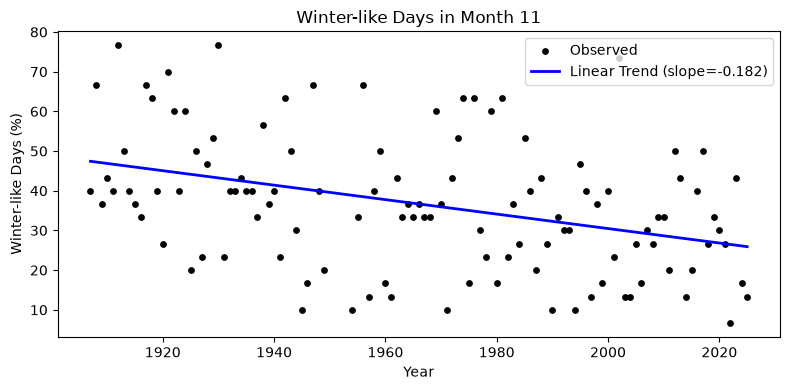

Winter - Month 3

[Linear Regression]
Slope: -0.381655 percentage points/year
Intercept: 804.0050
R²: 0.4202
p-value: 3.66293e-15
Change per 100 years: -38.17 percentage points

[Mann-Kendall Test]
Trend: decreasing
p-value: 2.91545e-13
Sen's slope: -0.403226


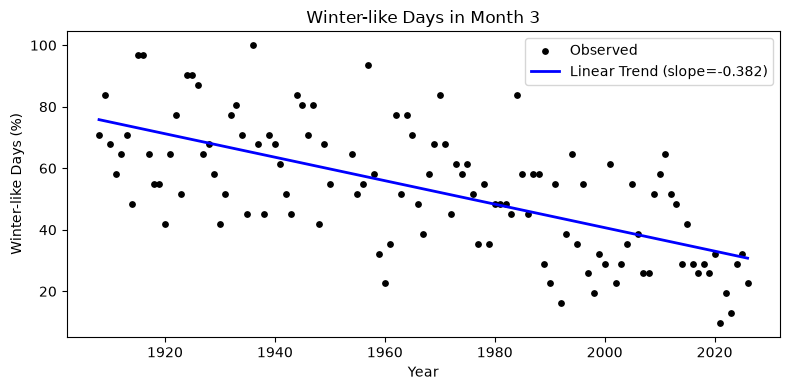

   season  month     slope  r_squared  linear_p_value  change_per_100_years  \
0  Summer      5  0.294130   0.504503    4.313749e-19             29.412997   
1  Summer      9  0.365840   0.503535    9.805088e-19             36.584039   
2  Winter     11 -0.182247   0.142225    3.259436e-05            -18.224708   
3  Winter      3 -0.381655   0.420173    3.662925e-15            -38.165456   

     mk_trend    mk_p_value  sen_slope  
0  increasing  2.220446e-16   0.286738  
1  increasing  2.220446e-16   0.386473  
2  decreasing  4.681497e-05  -0.181159  
3  decreasing  2.915446e-13  -0.403226  


In [20]:
# 5월 분석:
may_result = analyze_trend(monthly_ratio, month=5, variable="summer_like_percent", season_name="Summer")

# 9월 분석:
sep_result = analyze_trend(monthly_ratio, month=9, variable="summer_like_percent", season_name="Summer")

# 11월 분석:
nov_result = analyze_trend(monthly_ratio, month=11, variable="winter_like_percent", season_name="Winter")

# 3월 분석:
mar_result = analyze_trend(monthly_ratio, month=3, variable="winter_like_percent", season_name="Winter")

# Combine:
seasonal_expansion_trend_results = pd.DataFrame([may_result, sep_result, nov_result, mar_result])
print(seasonal_expansion_trend_results)

# Save:
seasonal_expansion_trend_results.to_csv(
    "../data/processed/seasonal_expansion_trend_results.csv",
    index=False,
    encoding="utf-8-sig"
)

결과 해석:

| 월 | 결과 | 해석 |
| ---- | --------------------- | --------------------------- |
| 5월  | R² = 0.505, p < 0.001 | 여름 유사 기온 비율이 유의하게 증가 (약 +29.4%p / 100년) |
| 9월  | R² = 0.504, p < 0.001 | 여름 유사 기온 비율이 유의하게 증가 (약 +36.6%p / 100년) |
| 11월 | R² = 0.142, p < 0.001 | 겨울 유사 기온 비율이 유의하게 감소 (약 −18.2%p / 100년), 하지만 연도별 변동도 상당함 |
| 3월  | R² = 0.420, p < 0.001 | 겨울 유사 기온 비율이 유의하게 감소 (약 −38.2%p / 100년) |

Sen's slope도 각각 +0.287, +0.386, −0.181, −0.403으로 비슷한 방향과 크기를 보여줌.

* 5월 / 9월의 여름 유사 기온 발생 비율이 (연평균 각각 약 +0.29%p / +0.37%p) 통계적으로 유의하게 증가하고 있으며, 11월 / 3월의 겨울 유사 기온 발생 비율이 (연평균 각각 약 -0.18%p / -0.38%p) 통계적으로 유의하게 감소하고 있음.
    * → 서울의 여름다운 기온이 기존 6~8월에서 5월과 9월 방향으로 확대되고 있고 겨울 유사 기온이 축소하고 있다는 근거.
    * → 이는 현재의 지표가 일평균기온 ≥ 20°C라는 정의에 기반한 결과이고 이에 따라 "5월과 9월의 여름 유사 기온 발생 비율이 증가했다"라고 볼 수 있다.

## Files saved

* `data/processed/seasonal_expansion_trend_results.csv`